# **SMS SPAM DETECTION**

SMS spam detection is an intelligent system designed to detect spam messages. Spam messages refer to unwanted, misleading, or fraudulent messages that are often sent in bulk by scammers for advertising, phishing, or financial fraud, whereas ham messages represent legitimate and important communications. With the rapid growth of digital communication, spam messages have become increasingly common and are often used by scammers to trick people into sharing sensitive information or losing money through fraudulent schemes. Therefore, developing an effective spam detection system is important to protect users and help filter out unwanted messages while allowing important messages to reach them.

The main objective of this project is to develop an effective SMS spam detection system that can automatically classify messages as spam or ham based on their textual content. To achieve this, various machine learning algorithms that perform well on textual data were implemented and evaluated. The models used in this project include Support Vector Machine (LinearSVC), Logistic Regression, Multinomial Naive Bayes, Random Forest Classifier, Extra Trees Classifier, and XGBoost Classifier. In addition to individual models, ensemble learning techniques such as Stacking Classifier and Voting Classifier were also applied to combine the strengths of multiple models. The performance of these models was compared using evaluation metrics such as accuracy and precision in order to identify the most effective approach for spam detection. The goal is to build a reliable model that can accurately identify spam messages while minimizing the risk of misclassifying legitimate messages.

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **LOADING DATASET**

In [109]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 69.9MB/s]



In [110]:
import zipfile

with zipfile.ZipFile('sms-spam-collection-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# **DATASET FIRST VIEW**

In [111]:
sms = pd.read_csv('/content/data/spam.csv', encoding='latin-1')
sms.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
# Number of rows and columns in the SMS Spam Dataset.
print("The Rows in SMS Spam Dataset = {}".format(sms.shape[0]))
print("The Columns in SMS Spam Dataset = {}".format(sms.shape[1]))

The Rows in SMS Spam Dataset = 5572
The Columns in SMS Spam Dataset = 5


# **DATASET DISCRIPTION**

The dataset used in this project was collected from Kaggle and is titled [SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset). The SMS Spam Collection is a set of SMS tagged messages that have been collected for SMS Spam research. It consists of a collection of SMS messages written in English that are labeled as either spam or ham (legitimate).

The dataset contains a total of 5,572 SMS messages, each tagged according to its category. Every record in the dataset represents a single SMS message. The dataset is organized in such a way that each line corresponds to one message and contains two columns:

- `v1` - The label (ham or spam)
- `v2` - The raw text.


# **DATA PREPROCESSING**

In [5]:
# Checking null value
sms.isnull().sum()

,0
v1,0
v2,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [6]:
# Drop the unwanted columns
sms.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [7]:
# Rename columns: v1 → label, v2 → text
sms.rename(columns={'v1': 'label', 'v2': 'text'}, inplace=True)
sms = sms[['text', 'label']]

In [8]:
# Function to convert spam → 1 and ham → 0
def label_encoding(obj):
  if obj == 'spam':
    return 1
  else:
    return 0

In [9]:
sms['label']=sms['label'].apply(label_encoding)

In [10]:
sms.head()

,text,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [11]:
sms.isnull().sum()

,0
text,0
label,0


In [12]:
# Check for duplicate values
sms.duplicated().sum()

np.int64(403)

In [13]:
# Drop duplicate values
sms.drop_duplicates(inplace=True)

In [14]:
# Check the number of rows and columns after preprocessing
print("The Rows in SMS Spam Dataset = {}".format(sms.shape[0]))
print("The Columns in SMS Spam Dataset = {}".format(sms.shape[1]))

The Rows in SMS Spam Dataset = 5169
The Columns in SMS Spam Dataset = 2


# **LABEL DISTRIBUTION**

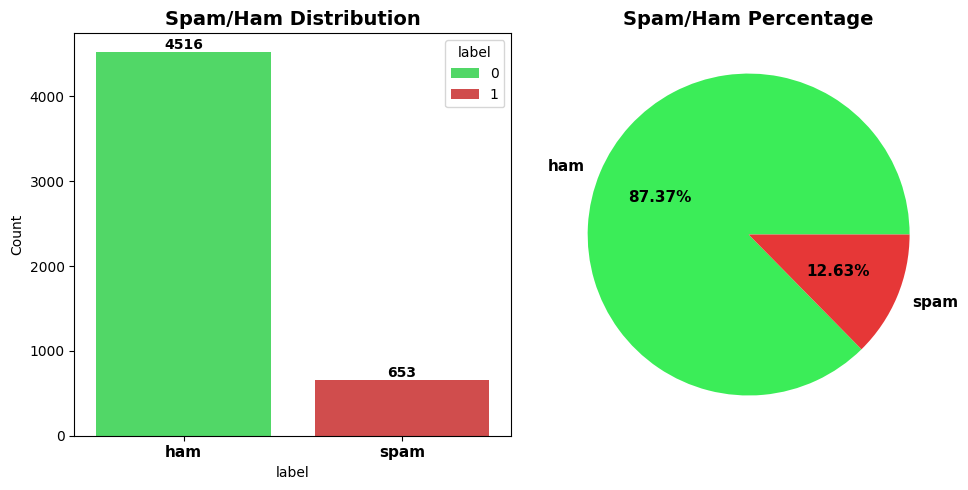

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Define colors using a dictionary for explicit mapping
colors_map = {0: '#3BED58', 1: '#E63737'}
# Create a count plot to visualize the number of ham and spam messages
sns.countplot(x='label', data=sms, hue='label', ax=axes[0], palette=colors_map, order=[0, 1])
# Add value labels on top of each bar in the count plot
for container in axes[0].containers:
    axes[0].bar_label(container, fontweight='bold')
# Set title and axis labels for the count plot
axes[0].set_title('Spam/Ham Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
# Customize x-axis ticks and labels
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['ham', 'spam'], fontsize=11, fontweight='bold')


# Define colors for the pie chart based on class distribution
pie_colors = [colors_map[label] for label in sms['label'].value_counts().index]
# Create custom labels for the pie chart
pie_labels_map = {0: 'ham', 1: 'spam'}
pie_chart_labels = [pie_labels_map[label] for label in sms['label'].value_counts().index]
# Create pie chart to show percentage distribution of ham and spam messages
axes[1].pie(sms['label'].value_counts(), labels=pie_chart_labels, autopct='%1.2f%%', colors=pie_colors, textprops = {'fontsize':11, 'weight':'bold'})
# Set title for the pie chart
axes[1].set_title('Spam/Ham Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The label distribution shows that 4516 (87.37%) messages are ham, while 653 (12.63%) messages are spam. This indicates that the dataset is highly imbalanced, as the number of ham messages is significantly higher than the number of spam messages. In such cases, machine learning models may become biased toward the majority class (ham), which can result in poor detection of spam messages. Therefore, relying only on accuracy may not provide a reliable evaluation of the model’s performance, especially when dealing with an imbalanced dataset.

In this project, precision is given higher importance as the primary evaluation metric. Precision measures how many of the messages predicted as spam are actually spam. This is particularly important in spam detection systems because misclassifying a legitimate message as spam (false positive) can cause users to miss important information.



# **AVERAGE LENGTH OF SMS FOR SPAM ABD HAM**

In [16]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
# Create a new column that stores the total number of characters in each message
sms['char_count'] = sms['text'].apply(lambda x: len(x))

# Create a column that counts the number of words in each message using NLTK word tokenizer
sms['word_count'] = sms['text'].apply(lambda x: len(nltk.word_tokenize(x)))

# Create a column that counts the number of sentences in each message using NLTK sentence tokenizer
sms['sent_count'] = sms['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [18]:
sms.head()

,text,label,char_count,word_count,sent_count
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2
1,Ok lar... Joking wif u oni...,0,29,8,2
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2
3,U dun say so early hor... U c already then say...,0,49,13,1
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1


In [19]:

a=sms[sms['label']==0]['char_count'].mean() # Calculate the average character length of ham messages
b=sms[sms['label']==1]['char_count'].mean() # Calculate the average character length of sham messages

In [20]:
c=sms[sms['label']==0]['word_count'].mean() # Calculate the average word length of ham messages
d=sms[sms['label']==1]['word_count'].mean() # Calculate the average word length of sham messages

In [21]:
e=sms[sms['label']==0]['sent_count'].mean() # Calculate the average sentence length of ham messages
f=sms[sms['label']==1]['sent_count'].mean() # Calculate the average sentence length of sham messages

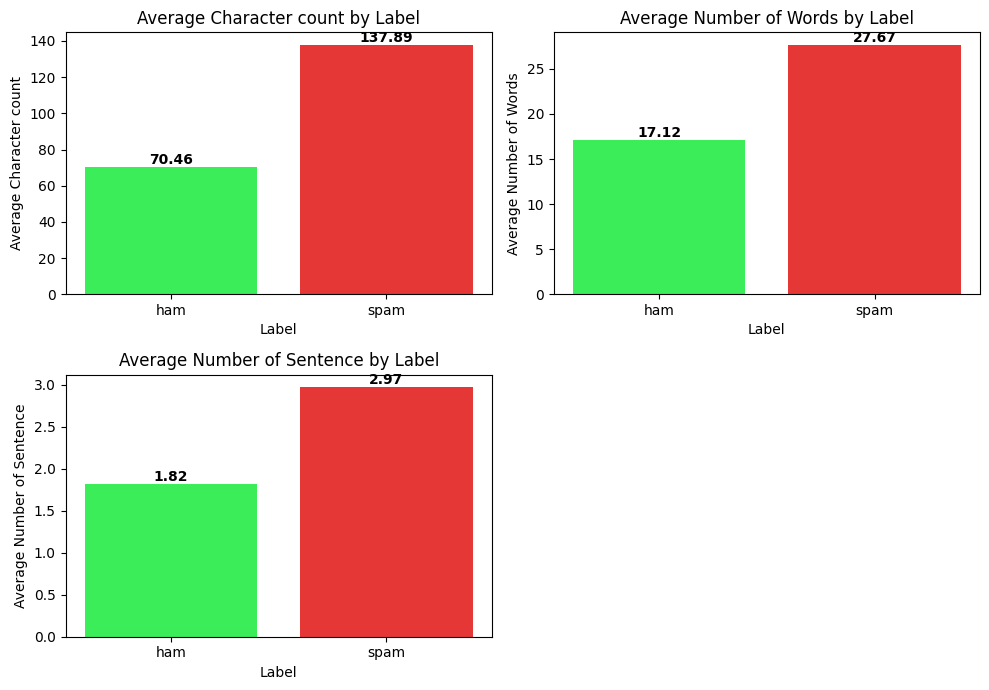

In [22]:
# Create subplots to display different text statistics for ham and spam messages
fig, axes = plt.subplots(2, 2, figsize=(10,7))

# Plot a bar chart showing the average number of characters in ham and spam messages
axes[0,0].bar(['ham', 'spam'], [a, b], color=['#3BED58','#E63737'])
axes[0,0].set_xlabel('Label')
axes[0,0].set_ylabel('Average Character count')
axes[0,0].set_title('Average Character count by Label')
axes[0,0].text('ham', a, f'{a:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0,0].text('spam', b, f'{b:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot a bar chart showing the average number of words in ham and spam messages
axes[0,1].bar(['ham', 'spam'], [c, d], color=['#3BED58','#E63737'])
axes[0,1].set_xlabel('Label')
axes[0,1].set_ylabel('Average Number of Words')
axes[0,1].set_title('Average Number of Words by Label')
axes[0,1].text('ham', c, f'{c:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0,1].text('spam', d, f'{d:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot a bar chart showing the average number of sentences in ham and spam messages
axes[1,0].bar(['ham', 'spam'], [e, f], color=['#3BED58','#E63737'])
axes[1,0].set_xlabel('Label')
axes[1,0].set_ylabel('Average Number of Sentence')
axes[1,0].set_title('Average Number of Sentence by Label')
axes[1,0].text('ham', e, f'{e:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1,0].text('spam', f, f'{f:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Turn off the unused subplot (bottom-right) for better layout
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

From the above graphs, it can be observed that the average number of characters in spam messages (138.87) is significantly higher than in ham messages (71.02). Similarly, the average number of words in spam messages (27.89) is also greater than in ham messages (17.28). In addition, the average number of sentences in spam messages (3.02) is higher compared to ham messages (1.84). This indicates that spam messages tend to be longer and contain more words and sentences. This may be because spam messages often include advertisements, promotional content, or misleading information designed to attract the reader’s attention. In contrast, legitimate messages are usually shorter and more direct.

# **RELATIONSHIP BETWEEN FEATURES**

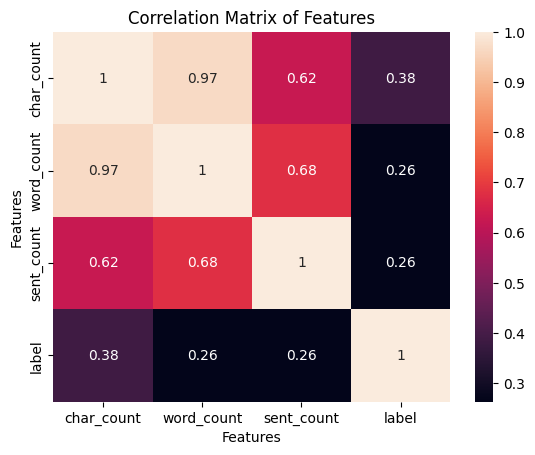

In [23]:
corre = sms[['char_count', 'word_count', 'sent_count', 'label']].corr()
# Visualize the correlation matrix using a heatmap
sns.heatmap(corre, annot=True)
plt.title('Correlation Matrix of Features')
plt.xlabel('Features')
plt.ylabel('Features')

plt.show()

The correlation matrix shows that the correlation between character count and word count is highly positive (0.97), indicating a strong relationship between these two features. This means that messages with more characters generally contain more words. Additionally, the correlation between word count and sentence count is moderate (0.68), suggesting that messages with more words tend to have more sentences. However, the correlation between character count and sentence count is slightly weaker (0.62). These relationships indicate that longer messages usually contain more words and sentences, which helps in understanding the structural patterns of the text data. Analyzing these correlations provides useful insights into how different textual features are related

# **TEXT PREPROCESSING**

In [24]:
# Import necessary libraries for text preprocessing
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [25]:
# Display the first SMS message from the dataset
sms['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [26]:
wl = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Function to preprocess text data
def text_preprocessing(obj):

  # Convert all characters in the text to lowercase
  obj = obj.lower()
  # Remove punctuation and special characters using regular expressions
  obj = re.sub(r'[^a-zA-Z0-9\s]', '', obj)
  # Split the text into individual words
  words = obj.split()
  # Remove common stopwords
  words = [word for word in words if word not in stop_words]
  # Apply lemmatization to convert words to their base form
  words = [wl.lemmatize(word) for word in words]
  # Join the processed words back into a single string and return the result
  return ' '.join(words)

In [27]:
sms['transform_text']=sms['text'].apply(text_preprocessing)

In [28]:
sms

,text,label,char_count,word_count,sent_count,transform_text
0,"Go until jurong point, crazy.. Available only ...",0,111,24,2,go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,0,29,8,2,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,0,49,13,1,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",0,61,15,1,nah dont think go usf life around though
...,...,...,...,...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1,161,35,4,2nd time tried 2 contact u u 750 pound prize 2...
5568,Will Ì_ b going to esplanade fr home?,0,37,9,1,b going esplanade fr home
5569,"Pity, * was in mood for that. So...any other s...",0,57,15,2,pity mood soany suggestion
5570,The guy did some bitching but I acted like i'd...,0,125,27,1,guy bitching acted like id interested buying s...


Text preprocessing was applied to clean and normalize the SMS messages before training the machine learning models. The text was converted to lowercase, and punctuation and special characters were removed using regular expressions. Stopwords were removed to eliminate common but less meaningful words, and lemmatization was applied to reduce words to their base form. Finally, the processed words were combined back into a cleaned text string. These steps help improve the quality of the text data and enhance model performance.

# **MOST COMMON WORD IN SPAM**

In [29]:
# Get all preprocessed spam messages as a list
spam_sms = sms[sms['label']==1]['transform_text'].tolist()
spam_sms[0:3]

['free entry 2 wkly comp win fa cup final tkts 21st may 2005 text fa 87121 receive entry questionstd txt ratetcs apply 08452810075over18s',
 'freemsg hey darling 3 week word back id like fun still tb ok xxx std chgs send 150 rcv',
 'winner valued network customer selected receivea 900 prize reward claim call 09061701461 claim code kl341 valid 12 hour']

In [30]:
# A list to store all words from spam messages
spam_word_corpus = []

# Loop through each spam message
for sent in spam_sms:
  # Split the message into individual words and add them to the corpus
  for word in sent.split():
    spam_word_corpus.append(word)

# Count the total number of words in the spam word corpus
print("Total number of words in spam messages:", len(spam_word_corpus))

Total number of words in spam messages: 10803


In [31]:
from collections import Counter
# Count the frequency of each word in the spam word corpus
spam_word_count=Counter(spam_word_corpus)

# Extract the 15 most common words from the spam corpus
most_common_spam_word = spam_word_count.most_common(15)
most_common_spam_word

[('call', 314),
 ('free', 188),
 ('2', 155),
 ('u', 130),
 ('txt', 126),
 ('text', 120),
 ('ur', 119),
 ('mobile', 114),
 ('stop', 103),
 ('claim', 98),
 ('4', 97),
 ('reply', 94),
 ('prize', 82),
 ('get', 69),
 ('new', 64)]

### Visualizing common spam words Using WordCloud
A WordCloud is a visualization technique used to display the most frequently occurring words in a text dataset. In a word cloud, words that appear more often in the text are shown in a larger size, while less frequent words appear smaller.

In [32]:
from wordcloud import WordCloud

# Create a wordcloud object
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

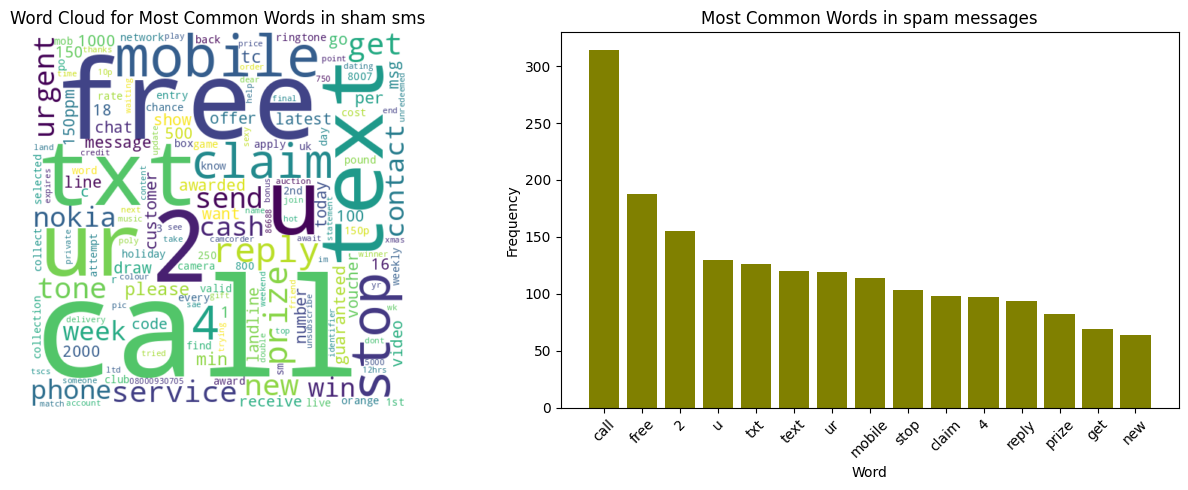

In [33]:
# Generate a wordcloud using the frequency of words in spam messages
spam_wordcloud = wc.generate_from_frequencies(dict(spam_word_count))

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Display the wordcloud visualization of the words
axes[0].imshow(spam_wordcloud, interpolation='bilinear')
axes[0].set_title('Word Cloud for Most Common Words in sham sms')
axes[0].axis('off')

# Plot the most common spam words using a bar chart
axes[1].bar([word[0] for word in most_common_spam_word], [word[1] for word in most_common_spam_word], color='olive')
axes[1].set_xlabel('Word')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(ticks=range(len(most_common_spam_word)), labels=[word[0] for word in most_common_spam_word], rotation=45)
axes[1].set_title('Most Common Words in spam messages')

plt.tight_layout()
plt.show()

The most common words in spam messages include terms such as call, free, mobile, and claim prize. These words are often used by spammers to attract attention and persuade users to respond to the message. By analyzing these frequently used words, we can better understand the strategies used in spam messages. This helps users recognize suspicious messages and avoid falling for scams.

# **MOST COMMON WORD IN HAM**

In [34]:
# Get all preprocessed ham messages as a list
sms_ham = sms[sms['label']==0]['transform_text'].tolist()
sms_ham[0:3]

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'u dun say early hor u c already say']

In [35]:
# A list to store all words from ham messages
ham_word_corpus=[]

# Loop through each ham message
for sent in sms_ham:
  # Split the message into individual words and add them to the corpus
  for word in sent.split():
    ham_word_corpus.append(word)

# Count the total number of words in the ham word corpus
print("Total number of words in ham messages:", len(ham_word_corpus))

Total number of words in ham messages: 36720


In [36]:
# Count the frequency of each word in the ham word corpus
ham_word_count = Counter(ham_word_corpus)

# Extract the 15 most common words from the ham corpus
most_common_ham_word = ham_word_count.most_common(15)
most_common_ham_word

[('u', 929),
 ('im', 443),
 ('get', 306),
 ('2', 288),
 ('go', 265),
 ('ltgt', 254),
 ('dont', 253),
 ('ok', 246),
 ('know', 229),
 ('got', 225),
 ('come', 223),
 ('like', 222),
 ('ill', 209),
 ('good', 206),
 ('time', 205)]

### Visualizing common ham words Using WordCloud

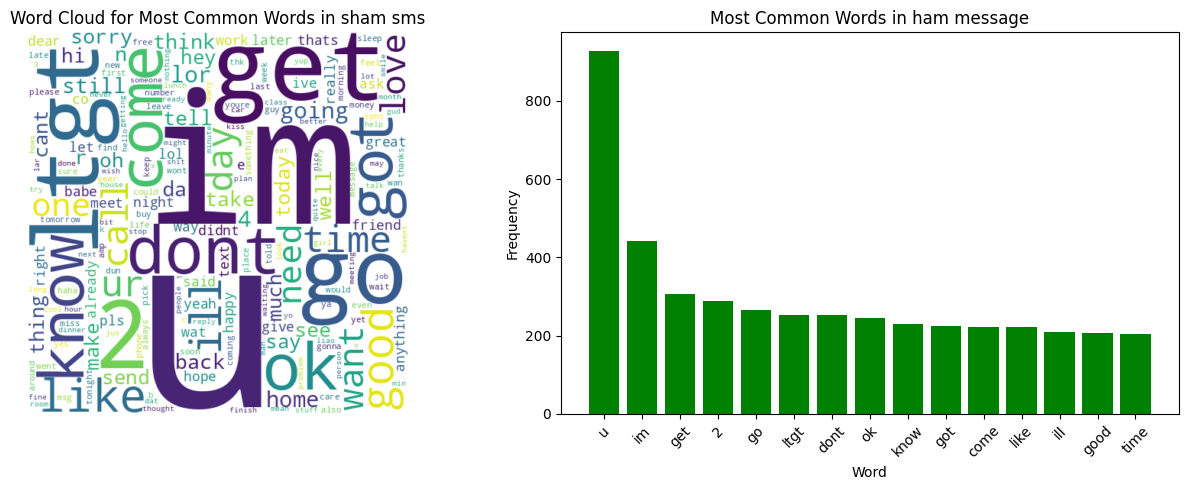

In [37]:
# Generate a wordcloud using the frequency of words in ham messages
ham_word_cloud = wc.generate_from_frequencies(dict(ham_word_count))

fig, axes = plt.subplots(1, 2, figsize=(13,5))

# Display the wordcloud visualization of the words
axes[0].imshow(ham_word_cloud, interpolation='bilinear')
axes[0].set_title('Word Cloud for Most Common Words in sham sms')
axes[0].axis('off')

# Plot the most common ham words using a bar chart
axes[1].bar([word[0] for word in most_common_ham_word], [word[1] for word in most_common_ham_word], color='green')
axes[1].set_xlabel('Word')
axes[1].set_ylabel('Frequency')
axes[1].set_xticks(ticks=range(len(most_common_ham_word)), labels=[word[0] for word in most_common_ham_word], rotation=45)
axes[1].set_title('Most Common Words in ham message')

plt.tight_layout()
plt.show()

The most common words in ham messages include terms such as u, im, get, 2, and it. These are commonly used in casual conversations between people. For example, u means you, im means I am, and 2 often represents to or too. Such words are typical in normal text messages where people communicate informally. Understanding these common patterns helps identify what regular messages look like, making it easier to distinguish legitimate messages from unusual or suspicious ones, such as spam.

# **MODEL IMPLEMENTATION**

Various machine learning models were implemented in this project to identify the most effective approach for spam detection. Since the dataset consists of textual data, several algorithms that perform well on text classification tasks were applied. These include Support Vector Machine (SVM), Multinomial Naive Bayes, Logistic Regression, Random Forest Classifier, Extra Trees Classifier, and XGBoost Classifier. In addition to individual models, ensemble techniques such as Stacking Classifier and Voting Classifier were also used to combine the strengths of multiple models. The performance of these models was evaluated using metrics such as accuracy and precision in order to determine the most suitable model for accurately classifying messages as spam or ham.

For model evaluation, I focused more on precision than accuracy. This is because the dataset is highly imbalanced, with many more ham messages than spam messages. If we rely only on accuracy, the model may become biased toward predicting ham messages. Precision is important because it helps reduce false positives, where a normal message (ham) is predicted as spam. If this happens, users may miss important messages. Therefore, prioritizing precision helps make sure that legitimate messages are not wrongly classified as spam.

In [38]:
# Import machine learning classification models

from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score

In [39]:
# X contains the preprocessed text messages
X = sms['transform_text']
# Y contains the corresponding labels (spam: 1 or ham: 0)
Y = sms['label']
# Split the dataset into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(X, Y, stratify=Y, test_size=0.2, random_state=42)

The dataset was divided into training and testing sets using the train_test_split function. The data was split with 80% used for training and 20% for testing. Stratified sampling was applied to maintain the same proportion of spam and ham messages in both sets, ensuring a fair evaluation of the model.

In [52]:
# List that store model accuracy and precision

Model_name = []
Model_acc = []
Model_pre = []

### Model 1: Support vector Machine
In classification problems, SVM works by finding the best boundary, called a hyperplane, that separates data points into different classes. The algorithm tries to maximize the distance between the hyperplane and the closest data points from each class, which are known as support vectors. By creating this optimal boundary, SVM can effectively distinguish between different categories.

In [53]:
# Create a pipeline that first converts text data into TF-IDF features
# and then apply the Support Vector Machine (LinearSVC) classifier
pipe_svm = Pipeline([('tfidf', TfidfVectorizer()), ('svm', LinearSVC())])

# Define hyperparameters to tune using GridSearchCV
param_grid_svm = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'svm__C': [0.1, 0.5, 1, 2]
}

In [54]:
# Apply GridSearchCV to find the best combination of hyperparameters for the SVM pipeline
grid_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=5, scoring= 'precision', n_jobs=-1)

In [55]:
# Train the GridSearchCV model on the training data
grid_svm.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('svm', LinearSVC())]),
             n_jobs=-1,
             param_grid={'svm__C': [0.1, 0.5, 1, 2],
                         'tfidf__max_features': [3000, 5000, 7000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='precision')

In [56]:
# Predict spam/ham labels for the test data
y_pred_svm = grid_svm.predict(x_test)

In [57]:
# Evaluate model performance using accuracy and precision
print('accuracy', accuracy_score(y_test, y_pred_svm))
print('precision', precision_score(y_test, y_pred_svm))

accuracy 0.9690522243713733
precision 0.9900990099009901


In [58]:
# Store SVM model results (name, accuracy, precision)
Model_name.append('SVM')
Model_acc.append(accuracy_score(y_test, y_pred_svm))
Model_pre.append(precision_score(y_test, y_pred_svm))

After applying the **Support Vector Machine (SVM)** model to the dataset, the model achieved a **precision** of **~ 0.990** and an **accuracy** of **~ 0.969**. The best performance was obtained using the TF-IDF parameters *max_features = 3000* and *ngram_range = (1, 2)*. For the LinearSVC classifier, the optimal hyperparameter was *C = 0.1*.

### Model 2: Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic machine learning algorithm commonly used for text classification. It is based on Bayes’ theorem and assumes that the features (words in the text) are independent of each other. The algorithm works by calculating the probability of a message belonging to a particular class based on the frequency of words present in the text. Because it handles word frequency information effectively, Multinomial Naive Bayes performs well on textual data.

In [59]:
# Create a pipeline that first converts text data into TF-IDF features
# and then apply the Multinomial Naive Bayes classifier
pipe_mnb = Pipeline([('tfidf', TfidfVectorizer()), ('mnb', MultinomialNB())])

In [60]:
# Define hyperparameters to tune using GridSearchCV
param_grid_mnb = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'mnb__alpha': [0.1, 0.5, 1.0, 2.0]
}

In [61]:
# Apply GridSearchCV to find the best combination of hyperparameters for the MNB pipeline
grid_mnb = GridSearchCV(
    pipe_mnb,
    param_grid_mnb,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

In [62]:
# Train the GridSearchCV model on the training data
grid_mnb.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('mnb', MultinomialNB())]),
             n_jobs=-1,
             param_grid={'mnb__alpha': [0.1, 0.5, 1.0, 2.0],
                         'tfidf__max_features': [3000, 5000, 7000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='precision')

In [63]:
# Predict spam/ham labels for the test data
y_pred_mnb = grid_mnb.predict(x_test)

In [64]:
# Evaluate model performance using accuracy and precision
print('accuracy', accuracy_score(y_test, y_pred_mnb))
print('precision', precision_score(y_test, y_pred_mnb))

accuracy 0.9709864603481625
precision 0.9809523809523809


In [65]:
# Store  MNB results (name, accuracy, precision)
Model_name.append('MNB')
Model_acc.append(accuracy_score(y_test, y_pred_mnb))
Model_pre.append(precision_score(y_test, y_pred_mnb))

After applying the **Multinomial Naive Bayes (MNB)** model to the dataset, the model achieved a **precision** of **~ 0.980** and an **accuracy** of **~ 0.0.970**. The best performance was obtained using the TF-IDF parameters *max_features = 3000* and *ngram_range = (1, 2)*.

### Model 3: Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification tasks. It predicts the probability of a data point belonging to a particular class using a logistic (sigmoid) function. Based on this probability, the model assigns the data to one of the predefined classes. Logistic Regression is simple, efficient, and widely used for binary classification problems.

In [66]:
# Create a pipeline that first converts text data into TF-IDF features
# and then apply the Logistic Regression
pipe_lr = Pipeline([('tfidf', TfidfVectorizer()), ('lr', LogisticRegression())])

In [67]:
# Define hyperparameters to tune using GridSearchCV
param_grid_lr = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'lr__C': [0.1, 0.5, 1, 2, 5],
    'lr__penalty': ['l2'],
    'lr__solver': ['liblinear']
}


In [68]:
# Apply GridSearchCV to find the best combination of hyperparameters
grid_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=5,
    scoring= 'precision',
    n_jobs=-1
)

In [69]:
# Train the GridSearchCV model on the training data
grid_lr.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('lr', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'lr__C': [0.1, 0.5, 1, 2, 5], 'lr__penalty': ['l2'],
                         'lr__solver': ['liblinear'],
                         'tfidf__max_features': [3000, 5000, 7000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='precision')

In [70]:
# Predict spam/ham labels for the test data
y_pred_lr = grid_lr.predict(x_test)

In [71]:
# Evaluate model performance using accuracy and precision
print('accuracy', accuracy_score(y_test, y_pred_lr))
print('precision', precision_score(y_test, y_pred_lr))

accuracy 0.9632495164410058
precision 0.9894736842105263


In [72]:
# Store LR model results (name, accuracy, precision)
Model_name.append('LR')
Model_acc.append(accuracy_score(y_test, y_pred_lr))
Model_pre.append(precision_score(y_test, y_pred_lr))

After applying the **Logistic Reggresion (LR)** model to the dataset, the model achieved a **precision** of **0.989** and an **accuracy** of **~ 0.963**. The best performance was obtained using the TF-IDF parameters *max_features = 3000* and *ngram_range = (1, 2)*. For the Logistic Regression, the optimal hyperparameter was *C = 5*, *solver='liblinear'*.

### Model 4: RandomForestClassifier

Random Forest Classifier is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to make the final decision. Each tree is trained on a random subset of the data and features, which helps reduce overfitting and improves model stability. By aggregating the results of many decision trees, Random Forest can achieve better performance and more reliable predictions compared to a single decision tree.

In [73]:
# Create a pipeline that first converts text data into TF-IDF features
# and then apply the Random Forest Classifier
pipe_rf = Pipeline([('tfidf', TfidfVectorizer()), ('rf', RandomForestClassifier(random_state=42))])

In [74]:
# Define hyperparameters to tune using GridSearchCV
param_grid_rf = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [None, 10, 20]
}

In [75]:
# Apply GridSearchCV to find the best combination of hyperparameters
grid_rf = GridSearchCV(
    pipe_rf,
    param_grid_rf,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

In [76]:
# Train the GridSearchCV model on the training data
grid_rf.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('rf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'rf__max_depth': [None, 10, 20],
                         'rf__n_estimators': [50, 100],
                         'tfidf__max_features': [3000, 5000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='precision')

In [77]:
# Predict spam/ham labels for the test data
y_pred_rf = grid_rf.predict(x_test)

In [78]:
# Evaluate model performance using accuracy and precision
print('accuracy', accuracy_score(y_test, y_pred_rf))
print('precision', precision_score(y_test, y_pred_rf))

accuracy 0.9061895551257253
precision 1.0


In [79]:
# Store RF model results (name, accuracy, precision)
Model_name.append('RF')
Model_acc.append(accuracy_score(y_test, y_pred_rf))
Model_pre.append(precision_score(y_test, y_pred_rf))

After applying the **Random Forest Classifier (RF)** to the dataset, the model achieved a **precision** of **1.00** and an **accuracy** of approximately **0.906**. The best performance was obtained using TF-IDF parameters with max_features = 5000 and ngram_range = (1, 2).

### Model 5: ExtraTreeClassifier

Extra Trees Classifier is an ensemble machine learning algorithm that builds multiple decision trees and combines their predictions to make the final result. Unlike Random Forest, it introduces more randomness by selecting split points randomly while building the trees. This additional randomness helps reduce overfitting and can improve the model's generalization. By aggregating the predictions from many trees, Extra Trees Classifier provides stable and reliable classification results.

In [80]:
# Create a pipeline that first converts text data into TF-IDF features
# and then apply the ExtraTree Classifier
pipe_et = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('et', ExtraTreesClassifier(random_state=42))
])

In [81]:
# Define hyperparameters to tune using GridSearchCV
param_grid_et = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'et__n_estimators': [50, 100],
    'et__max_depth': [None, 10, 20]
}

In [82]:
# Apply GridSearchCV to find the best combination of hyperparameters
grid_et = GridSearchCV(
    pipe_et,
    param_grid_et,
    cv=5,
    scoring = 'precision',
    n_jobs=-1
)

In [83]:
# Train the GridSearchCV model on the training data
grid_et.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('et',
                                        ExtraTreesClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'et__max_depth': [None, 10, 20],
                         'et__n_estimators': [50, 100],
                         'tfidf__max_features': [3000, 5000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='precision')

In [84]:
# Predict spam/ham labels for the test data
y_pred_et = grid_et.predict(x_test)

In [85]:
# Evaluate model performance using accuracy and precision
print('accuracy', accuracy_score(y_test, y_pred_et))
print('precision', precision_score(y_test, y_pred_et))

accuracy 0.8926499032882012
precision 1.0


In [86]:
# Store ET model results (name, accuracy, precision)
Model_name.append('ET')
Model_acc.append(accuracy_score(y_test, y_pred_et))
Model_pre.append(precision_score(y_test, y_pred_et))

After applying the **ExtraTree Classifier (ET)** to the dataset, the model achieved a **precision** of **1.00** and an **accuracy** of approximately **0.892**. The best performance was obtained using TF-IDF parameters with *max_features = 3000* and *ngram_range = (1, 2)*. For the Extra Trees model, the optimal hyperparameters were *max_depth = 10* and *n_estimators = 50*.

### Model 6: XGBoost Classifier

XGBoost Classifier (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm based on the gradient boosting technique. It builds multiple decision trees sequentially, where each new tree tries to correct the errors made by the previous ones. By combining the predictions of many trees, XGBoost improves model accuracy and reduces overfitting. It is known for its high performance, efficiency, and ability to handle complex datasets, making it widely used in many machine learning applications.

In [87]:
# Create a pipeline that first converts text data into TF-IDF features
# and then apply the XG Boosting Classifier
pipe_xgb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('xgb', XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ))
])

In [88]:
# Define hyperparameters to tune using GridSearchCV
param_grid_xgb = {
    'tfidf__max_features': [3000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'xgb__n_estimators': [50, 100],
    'xgb__max_depth': [None, 5, 10],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample': [0.8, 1.0]
}

In [89]:
# Apply GridSearchCV to find the best combination of hyperparameters
grid_xgb = GridSearchCV(
    pipe_xgb,
    param_grid_xgb,
    cv=5,
    scoring='precision',
    n_jobs=-1
)

In [90]:
# Train the GridSearchCV model on the training data
grid_xgb.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:32:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf', TfidfVectorizer()),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='logloss',
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      grow_poli...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'tfidf__max_features': [3000, 5000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)],
                         'xgb__learning_rate': [0.05, 0.1],
                         'xgb__max_depth': [None, 5, 10],
                         'xgb__n_estimators': [50, 100],
                         'xgb__subsample': [0.8, 1.0]},
             scoring='precision')

In [91]:
# Predict spam/ham labels for the test data
y_pred_xgb = grid_xgb.predict(x_test)

In [92]:
# Evaluate model performance using accuracy and precision
print('accuracy', accuracy_score(y_test, y_pred_xgb))
print('precision', precision_score(y_test, y_pred_xgb))

accuracy 0.9661508704061895
precision 0.9210526315789473


In [93]:
# Store XGB model results (name, accuracy, precision)
Model_name.append('XGB')
Model_acc.append(accuracy_score(y_test, y_pred_xgb))
Model_pre.append(precision_score(y_test, y_pred_xgb))

After applying the XGBoost Classifier (XGB) to the dataset, the model achieved a **Precision** of **~ 0.921** and an **Accuracy** of  **~ 0.966**. The best performance was obtained using TF-IDF parameters with *max_features = 5000* and *ngram_range = (1, 2)*. For the XGBoost model, the optimal hyperparameters were *max_depth = 10*, *n_estimators = 100*, and *learning_rate = 0.5*.

### Model Performance Comparision

In [94]:
# Create a DataFrame to store model names along with their accuracy and precision scores
# Sort the DataFrame in descending order based on precision
Model_result = pd.DataFrame({'Model': Model_name, 'Accuracy': Model_acc, 'Precision': Model_pre}).sort_values('Precision', ascending=False)
Model_result

,Model,Accuracy,Precision
4,ET,0.892650,1.000000
3,RF,0.906190,1.000000
0,SVM,0.969052,0.990099
2,LR,0.963250,0.989474
1,MNB,0.970986,0.980952
5,XGB,0.966151,0.921053


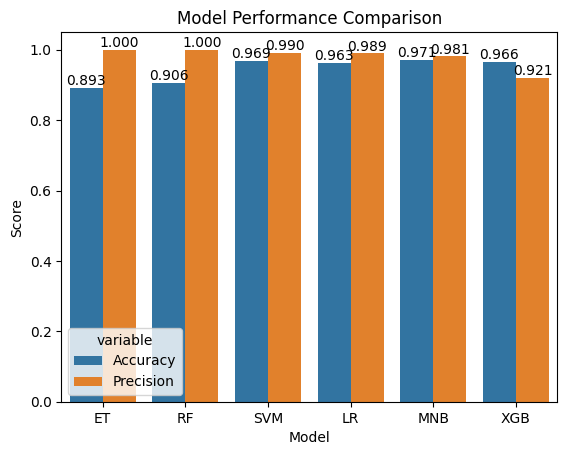

In [95]:
# Plot Accuracy vs Precision comparison with value labels
df_melt = Model_result.melt(id_vars='Model', value_vars=['Accuracy', 'Precision'])
ax = sns.barplot(data=df_melt, x='Model', y='value', hue='variable')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f')
plt.xticks()
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.show()

As observed, the XGBoost classifier achieved a precision of 0.921, which is lower compared to the other models. Since precision is the primary evaluation metric in this project, this performance is not sufficient. Therefore, the XGBoost classifier was not selected for inclusion in the stacking and voting ensemble models.

### **Model 8: Stacking Classifier**

Stacking Classifier is an ensemble learning technique that combines multiple machine learning models to improve prediction performance. In this method, several base models are trained on the same dataset, and their predictions are then used as input for another model called the meta-model. The meta-model learns how to best combine the predictions from the base models to produce the final output.

In [96]:
# Function to train and evaluate different stacking classifier combinations

def stacking_classifier(stacking, x_train=x_train, y_train=y_train):

  """
  Train and evaluate multiple stacking classifier models using a TF-IDF pipeline.

  This function takes a dictionary of stacking classifier models, applies TF-IDF
  vectorization for text feature extraction, and evaluates each model on the test dataset.
  It returns a DataFrame containing the accuracy and precision scores for comparison.

  Parameters:
  ----------
  stacking : dict
    A dictionary containing different stacking classifier configurations.
    Keys represent model names and values are StackingClassifier objects.

  x_train : array-like, default=x_train
    Training data (preprocessed text).

  y_train : array-like, default=y_train
    Training labels (spam or ham).

  Returns:
  -------
  pandas.DataFrame
    A DataFrame containing:
    - 'Stacking Classifier' : Name of the model
    - 'Accuracy' : Accuracy score of each model
    - 'Precision' : Precision score of each model
  """

  # Lists to store accuracy and precision results for each stacking model
  stacking_accuracy = []
  stacking_precision = []
  for i in stacking:

    # Create a pipeline that converts text into TF-IDF features
    # and applies the stacking classifier
    sc_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
        ('stacking', stacking[i])
    ])
    # Train the pipeline on the training dataset
    sc_pipe.fit(x_train, y_train)
    # Predict labels for the test dataset
    y_pred = sc_pipe.predict(x_test)

    # Store evaluation metrics (accuracy and precision)
    stacking_accuracy.append(accuracy_score(y_test, y_pred))
    stacking_precision.append(precision_score(y_test, y_pred))

  # Return the results as a DataFrame
  return pd.DataFrame({'Stacking Classifier': list(stacking.keys()), 'Accuracy': stacking_accuracy, 'Precision': stacking_precision})


In [97]:
# Define different combinations of stacking models
# Each stacking model uses three base classifiers and a Random Forest as the final meta-classifier
stacking = {
    'svc_mnb_lr': StackingClassifier(estimators=[('svc', LinearSVC()), ('mnb', MultinomialNB()), ('lr', LogisticRegression(solver='liblinear'))], final_estimator=RandomForestClassifier(), cv=5),
    'svc_mnb_rf': StackingClassifier(estimators=[('svc', LinearSVC()), ('mnb', MultinomialNB()), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=RandomForestClassifier(), cv=5),
    'mnb_lr_rf': StackingClassifier(estimators=[('mnb', MultinomialNB()), ('lr', LogisticRegression(solver='liblinear')), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=RandomForestClassifier(), cv=5),
    'svc_etc_rf': StackingClassifier(estimators=[('svc', LinearSVC()), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=RandomForestClassifier(), cv=5),
    'lr_etc_rf': StackingClassifier(estimators=[('lr', LogisticRegression(solver='liblinear')), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=RandomForestClassifier(), cv=5),
    'mnb_etc_rf': StackingClassifier(estimators=[('mnb', MultinomialNB()), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=RandomForestClassifier(), cv=5)
}

In [98]:
stc = stacking_classifier(stacking)
stc.sort_values('Precision', ascending=False)

,Stacking Classifier,Accuracy,Precision
4,lr_etc_rf,0.984526,0.975207
2,mnb_lr_rf,0.981625,0.959016
3,svc_etc_rf,0.981625,0.959016
0,svc_mnb_lr,0.976789,0.949580
1,svc_mnb_rf,0.980658,0.944000
5,mnb_etc_rf,0.980658,0.944000


After evaluating multiple stacking combinations with Random Forest as the meta-classifier, the best model achieved a **precision** of approximately **0.975** and an **accuracy** of approximately **0.984**.

In [99]:
# Define different combinations of stacking models
# Each stacking model uses three base classifiers and a ExtraTreeS as the final meta-classifier

stacking_1 = {
    'svc_mnb_lr': StackingClassifier(estimators=[('svc', LinearSVC()), ('mnb', MultinomialNB()), ('lr', LogisticRegression(solver='liblinear'))], final_estimator=ExtraTreesClassifier(), cv=5),
    'svc_mnb_rf': StackingClassifier(estimators=[('svc', LinearSVC()), ('mnb', MultinomialNB()), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=ExtraTreesClassifier(), cv=5),
    'mnb_lr_rf': StackingClassifier(estimators=[('mnb', MultinomialNB()), ('lr', LogisticRegression(solver='liblinear')), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=ExtraTreesClassifier(), cv=5),
    'svc_etc_rf': StackingClassifier(estimators=[('svc', LinearSVC()), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=ExtraTreesClassifier(), cv=5),
    'lr_etc_rf': StackingClassifier(estimators=[('lr', LogisticRegression(solver='liblinear')), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=ExtraTreesClassifier(), cv=5),
    'mnb_etc_rf': StackingClassifier(estimators=[('mnb', MultinomialNB()), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))], final_estimator=ExtraTreesClassifier(), cv=5)
}

In [100]:
stc_1 = stacking_classifier(stacking_1)
stc_1.sort_values('Precision', ascending=False)

,Stacking Classifier,Accuracy,Precision
4,lr_etc_rf,0.984526,0.967480
3,svc_etc_rf,0.983559,0.967213
1,svc_mnb_rf,0.981625,0.966667
2,mnb_lr_rf,0.977756,0.957627
0,svc_mnb_lr,0.972921,0.925620
5,mnb_etc_rf,0.975822,0.907692


After applying the Stacking Classifier, it was observed that when **Random Forest** was used as the final estimator, the model achieved the highest **precision** of approximately **0.967** along with an **accuracy** of **0.984**. When **Extra Tree** was used as the final estimator, the model achieved a slightly lower precision of approximately 0.967 and an accuracy of 0.983. However, despite these results, the stacking approach did not show a significant improvement compared to other models and can be considered to have relatively lower performance in this context.

### **Model 9: Voting Classifier**

Voting Classifier is an ensemble machine learning technique that combines the predictions of multiple models to make a final decision. Instead of relying on a single model, it aggregates the outputs of several classifiers to improve overall performance. There are two main types of voting: hard voting, where the final prediction is based on majority voting, and soft voting, where the average of predicted probabilities is used. By combining different models, the Voting Classifier helps improve accuracy and provides more stable and reliable predictions.

In [101]:
def voting_classifier(voting, x_train=x_train, y_train=y_train):
  """
  Train and evaluate multiple Voting Classifier models with hyperparameter tuning.

  This function applies TF-IDF vectorization and evaluates different Voting Classifier
  combinations using GridSearchCV to find the best weights for each model.
  It returns a DataFrame containing accuracy and precision scores for comparison.

  Parameters:
  ----------
  voting : dict
      Dictionary of VotingClassifier models where keys are model names
      and values are VotingClassifier objects.

  x_train : array-like
      Training data (preprocessed text).

  y_train : array-like
      Training labels (spam or ham).

  Returns:
  -------
  pandas.DataFrame
      DataFrame containing:
      - 'Voting Classifier' : Model names
      - 'Accuracy' : Accuracy score
      - 'Precision' : Precision score
  """

  # Lists to store evaluation metrics for each voting model
  voting_accuracy = []
  voting_precision = []
  voting_estimator = []
  for i in voting:

    # Create pipeline with TF-IDF vectorization and Voting Classifier
    vc_pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
        ('voting', voting[i])
    ])

    # Define weight combinations for tuning the voting classifier
    param_grid = {'voting__weights': [[1,1,1],[2,1,1], [1,2,1],[1,1,2],[2,2,1],[2,1,2],[1,2,2]]}
    # Apply GridSearchCV to find the best weights based on precision
    grid_vc = GridSearchCV(vc_pipe, param_grid, cv=5, scoring='precision', n_jobs=-1)
    # Train the model on training data
    grid_vc.fit(x_train, y_train)
    # Predict labels for the test data
    y_pred = grid_vc.predict(x_test)
    # Store evaluation metrics
    voting_accuracy.append(accuracy_score(y_test, y_pred))
    voting_precision.append(precision_score(y_test, y_pred))
    voting_estimator.append(grid_vc.best_estimator_)
  # Return results as a DataFrame
  return pd.DataFrame({'Voting Classifier': list(voting.keys()), 'Accuracy': voting_accuracy, 'Precision': voting_precision, 'Estimator': voting_estimator})

In [102]:
# Define different combinations of Voting Classifier models
# Each model combines three base classifiers to improve prediction performance
voting = {
    'svc_mnb_lr': VotingClassifier(
        estimators=[('svc', LinearSVC()), ('mnb', MultinomialNB()), ('lr', LogisticRegression(solver='liblinear'))],
        voting='hard'
    ),
    'svc_mnb_rf': VotingClassifier(
        estimators=[('svc', LinearSVC()), ('mnb', MultinomialNB()), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))],
        voting='hard'
    ),
    'mnb_lr_rf': VotingClassifier(
        estimators=[('mnb', MultinomialNB()), ('lr', LogisticRegression(solver='liblinear')), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))],
        voting='soft'
    ),
    'svc_etc_rf': VotingClassifier(
        estimators=[('svc', LinearSVC()), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))],
        voting='hard'
    ),
    'lr_etc_rf': VotingClassifier(
        estimators=[('lr', LogisticRegression(solver='liblinear')), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))],
        voting='soft'
    ),
    'mnb_etc_rf': VotingClassifier(
        estimators=[('mnb', MultinomialNB()), ('etc', ExtraTreesClassifier(n_estimators=50, random_state=42)), ('rf', RandomForestClassifier(n_estimators=50, random_state=42))],
        voting='soft'
    )
}

In [103]:
vc = voting_classifier(voting)
vc.sort_values('Precision', ascending=False)

,Voting Classifier,Accuracy,Precision,Estimator
4,lr_etc_rf,0.974855,1.000000,"(TfidfVectorizer(max_features=3000, ngram_rang..."
2,mnb_lr_rf,0.971954,1.000000,"(TfidfVectorizer(max_features=3000, ngram_rang..."
5,mnb_etc_rf,0.975822,1.000000,"(TfidfVectorizer(max_features=3000, ngram_rang..."
1,svc_mnb_rf,0.979691,0.991071,"(TfidfVectorizer(max_features=3000, ngram_rang..."
0,svc_mnb_lr,0.971954,0.990385,"(TfidfVectorizer(max_features=3000, ngram_rang..."
3,svc_etc_rf,0.973888,0.972727,"(TfidfVectorizer(max_features=3000, ngram_rang..."


In [66]:
vc['Estimator'][5]

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
                ('voting',
                 VotingClassifier(estimators=[('mnb', MultinomialNB()),
                                              ('etc',
                                               ExtraTreesClassifier(n_estimators=50,
                                                                    random_state=42)),
                                              ('rf',
                                               RandomForestClassifier(n_estimators=50,
                                                                      random_state=42))],
                                  voting='soft', weights=[2, 1, 1]))])

After applying the Voting Classifier, the model achieved the highest **Precision** of **1.00** along with an **Accuracy** of approximately **0.975**. The best performance was obtained using Multinomial Naive Bayes, ExtraTress, and Random Forest as base classifiers. The model used **weighted voting**, where the weights were set to [2, 1, 1], giving higher importance to the Multinomial Naive Bayes classifier.

# **SPAM OR HAM SMS PREDICTION**

After experimenting with different machine learning models, the best performance was achieved using the Voting Classifier. The model obtained a precision of 1.00 along with an accuracy of approximately 0.975. This result was achieved by combining Multinomial Naive Bayes, ExtraTrees, and Random Forest as base models. Based on its superior performance, this model is selected as the final model for spam or ham prediction.

In [40]:
# Define the final Voting Classifier model for Prediction
final_model = VotingClassifier(
    estimators=[
        ('mnb', MultinomialNB()),
        ('lr', ExtraTreesClassifier(n_estimators=50, random_state=42)),
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42))
    ],
    voting='soft',
    weights=[2,1,1]
)

In [41]:
# Create pipeline
final_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, ngram_range=(1,2))),
    ('model', final_model)
])

In [42]:
# Train
final_pipe.fit(x_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=3000, ngram_range=(1, 2))),
                ('model',
                 VotingClassifier(estimators=[('mnb', MultinomialNB()),
                                              ('lr',
                                               ExtraTreesClassifier(n_estimators=50,
                                                                    random_state=42)),
                                              ('rf',
                                               RandomForestClassifier(n_estimators=50,
                                                                      random_state=42))],
                                  voting='soft', weights=[2, 1, 1]))])

In [43]:
# Predict
y_pred_final = final_pipe.predict(x_test)

In [44]:
# Evaluate accuracy and precision
print('accuracy', accuracy_score(y_test, y_pred_final))
print('precision', precision_score(y_test, y_pred_final))

accuracy 0.9758220502901354
precision 1.0


In [45]:
def check_spam_ham(sms):

    """
    Predict whether a given SMS message is spam or ham.

    This function preprocesses the input text by converting it to lowercase,
    removing punctuation and special characters, removing stopwords, and
    applying lemmatization. The processed text is then passed to the trained
    machine learning pipeline to predict whether the message is spam or ham.

    Parameters:
    ----------
    sms : str
        The input SMS message to be classified.

    Returns:
    -------
    None
        Prints whether the input message is classified as 'Spam' or 'Ham'.
    """

    # Text Preprocessing
    obj = sms.lower()
    obj = re.sub(r'[^a-zA-Z0-9\s]', '', obj)
    words = obj.split()
    words = [word for word in words if word not in stop_words]
    words = [wl.lemmatize(word) for word in words]
    obj = ' '.join(words)

    # Pass the preprocessed message as a list
    prediction = final_pipe.predict([obj])
    if prediction[0] == 1:
        print("{} : Spam message".format(sms))
    else:
        print("{} : Ham message".format(sms))

In [48]:
spam_message = [
    "Congratulations! You have won a ₹10,000 gift voucher. Click here to claim now.",
    "URGENT! Your account has been suspended. Verify your details immediately.",
    "Win a free iPhone now! Limited offer, click the link below.",
    "You have been selected for a cash prize. Call now to claim your reward.",
    "Get cheap loans instantly! No documents required. Apply today.",
    "Free entry in a weekly contest! Reply WIN to participate."
]

In [49]:
for i in spam_message:
    check_spam_ham(i)

Congratulations! You have won a ₹10,000 gift voucher. Click here to claim now. : Spam message
URGENT! Your account has been suspended. Verify your details immediately. : Spam message
Win a free iPhone now! Limited offer, click the link below. : Spam message
You have been selected for a cash prize. Call now to claim your reward. : Spam message
Get cheap loans instantly! No documents required. Apply today. : Ham message
Free entry in a weekly contest! Reply WIN to participate. : Spam message


In [50]:
Ham_message = [
    "Hey, are we meeting today at 5 pm?",
    "I will call you later, I am in a meeting.",
    "Can you send me the notes from yesterday's class?",
    "Let’s go for dinner tonight.",
    "I have reached home safely.",
    "Please remind me to submit the assignment tomorrow."
]

In [51]:
for i in Ham_message:
  check_spam_ham(i)

Hey, are we meeting today at 5 pm? : Ham message
I will call you later, I am in a meeting. : Ham message
Can you send me the notes from yesterday's class? : Ham message
Let’s go for dinner tonight. : Ham message
I have reached home safely. : Ham message
Please remind me to submit the assignment tomorrow. : Ham message


### **RESULT**

A total of 6 spam and 6 ham messages were used to test the model. The model correctly predicted 5 out of 6 spam messages and all 6 ham messages correctly. Although one spam message was misclassified as ham, this is less critical compared to misclassifying a legitimate message as spam. Misclassifying a ham message as spam (false positive) may cause users to miss important information. Therefore, the model performs well by minimizing such errors and ensuring reliable spam detection.

# **CONCLUSION**

In this project, an SMS Spam Detection system was developed using various machine learning algorithms and ensemble techniques. Different models such as Support Vector Machine, Multinomial Naive Bayes, Logistic Regression, Random Forest, Extra Trees, and XGBoost were implemented and evaluated to identify the most effective approach for classifying messages as spam or ham. Since the dataset was imbalanced, precision was prioritized to reduce false positives and ensure that legitimate messages were not misclassified as spam.

Among all the models, the Voting Classifier achieved the best performance, with a precision of 1.00 and an accuracy of approximately 0.975. It combined Multinomial Naive Bayes, Extra Trees, and Random Forest with optimized weights to improve prediction performance. Although stacking techniques were also explored, they did not provide significant improvement compared to voting.